In [1]:
%load_ext autoreload
%autoreload 2

# B6 (partie 1) — Préparation des données images (MVTec AD)

Objectif : préparer un jeu de données industriel pour une future détection d'anomalies par auto-encodeur (partie 2).
On travaille sur la catégorie **`screw`** (déjà téléchargée dans `deep-learning/screw/`).

## Étape 1 — Préparer les données
- Charger les images, les **redimensionner** et les **normaliser** dans `[0, 1]`.
- Réserver une fraction des **saines** pour la **validation**.
- Vérifier visuellement le chargement (saines vs défauts).

In [2]:
from pathlib import Path

import cv2
import numpy as np

DATA_DIR = Path('screw')
IMG_SIZE = 128
VAL_FRACTION = 0.2
SEED = 42

TRAIN_GOOD_DIR = DATA_DIR / 'train' / 'good'
TEST_DIR = DATA_DIR / 'test'

defect_types = sorted(p.name for p in TEST_DIR.iterdir() if p.is_dir() and p.name != 'good')
print('Catégorie      :', DATA_DIR.name)
print('Défauts connus :', defect_types)

Catégorie      : screw
Défauts connus : ['manipulated_front', 'scratch_head', 'scratch_neck', 'thread_side', 'thread_top']


In [3]:
def load_image(path, size=IMG_SIZE):
    """Charge en niveaux de gris et redimensionne — image brute (uint8, [0, 255])."""
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    return img[..., np.newaxis]  # (H, W, 1), uint8


def load_folder(folder, size=IMG_SIZE):
    paths = sorted(Path(folder).glob('*.png'))
    images = np.stack([load_image(p, size) for p in paths])
    return images, paths

On charge les images **saines** d'entraînement, puis on réserve une fraction pour la validation :

In [4]:
train_good, train_good_paths = load_folder(TRAIN_GOOD_DIR)
print('Saines (train) :', train_good.shape)

rng = np.random.default_rng(SEED)
indices = rng.permutation(len(train_good))
n_val = int(len(train_good) * VAL_FRACTION)
val_idx, train_idx = indices[:n_val], indices[n_val:]

X_train, X_val = train_good[train_idx], train_good[val_idx]
print('Train :', X_train.shape, '| Validation :', X_val.shape)

Saines (train) : (320, 128, 128, 1)
Train : (256, 128, 128, 1) | Validation : (64, 128, 128, 1)


On charge aussi le jeu de test (saines + défauts), utile pour l'évaluation en partie 2 :

In [5]:
test_good, _ = load_folder(TEST_DIR / 'good')

test_defects = {}
for defect in defect_types:
    imgs, _ = load_folder(TEST_DIR / defect)
    test_defects[defect] = imgs

print('Test saines :', test_good.shape)
for defect, imgs in test_defects.items():
    print(f'Test {defect:<18}:', imgs.shape)

Test saines : (41, 128, 128, 1)
Test manipulated_front : (24, 128, 128, 1)
Test scratch_head      : (24, 128, 128, 1)
Test scratch_neck      : (25, 128, 128, 1)
Test thread_side       : (23, 128, 128, 1)
Test thread_top        : (23, 128, 128, 1)


*Attendu* : afficher quelques saines et quelques défauts pour vérifier le chargement.

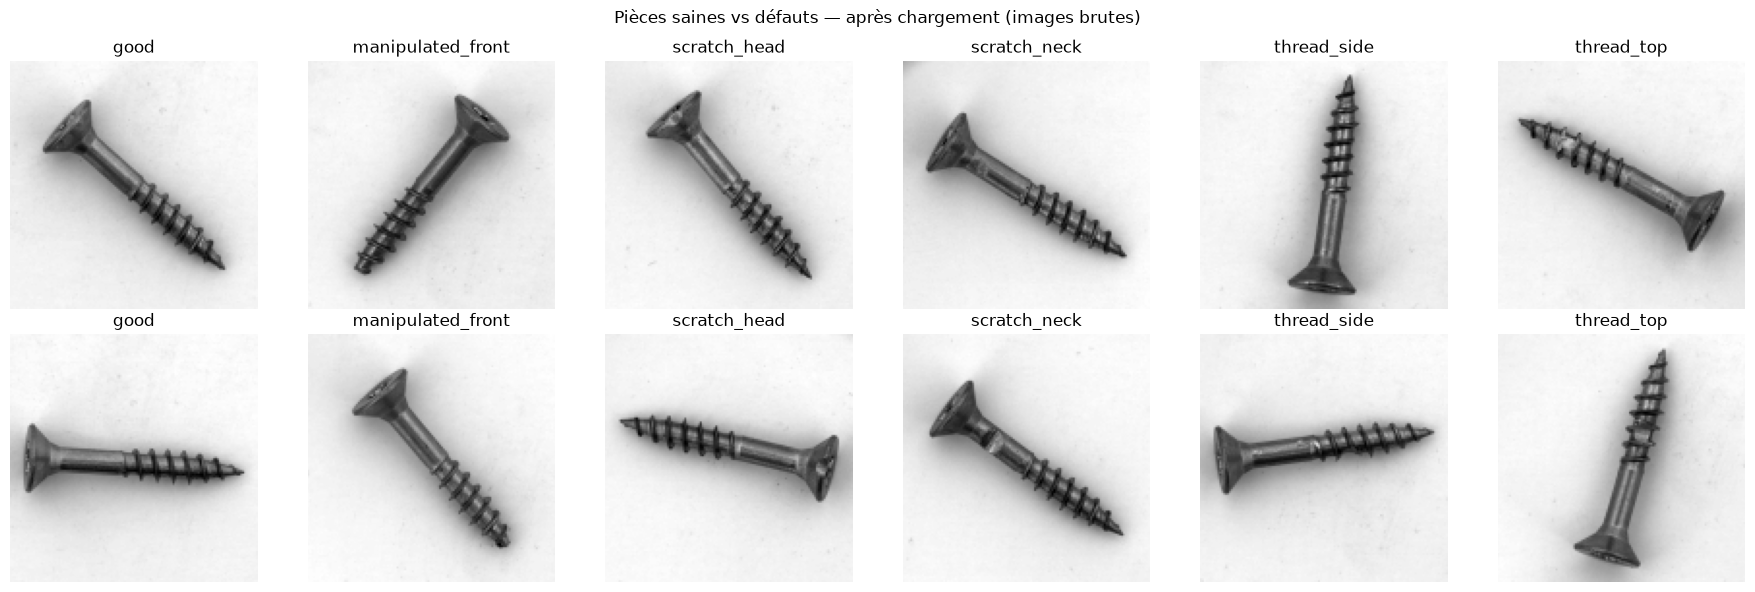

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, len(defect_types) + 1, figsize=(3 * (len(defect_types) + 1), 6))

for i in range(2):
    axes[i, 0].imshow(test_good[i, ..., 0], cmap='gray')
    axes[i, 0].set_title('good')
    for j, defect in enumerate(defect_types, start=1):
        axes[i, j].imshow(test_defects[defect][i, ..., 0], cmap='gray')
        axes[i, j].set_title(defect)

for ax in axes.ravel():
    ax.axis('off')

fig.suptitle('Pièces saines vs défauts — après chargement (images brutes)')
fig.tight_layout()
plt.show()

## Étape 2 — Augmenter les données (Albumentations)

Pipeline appliqué **uniquement aux saines d'entraînement** : flips, rotations légères, translation/échelle,
variations d'éclairage.

*Attendu* : visualiser original vs versions augmentées.

In [7]:
import albumentations as A

augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=15, border_mode=cv2.BORDER_REFLECT101, p=0.5),
    A.Affine(translate_percent=0.05, scale=(0.95, 1.05), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
])


def augment_image(img):
    """img est déjà brut (uint8) — Albumentations travaille nativement dans [0, 255]."""
    return augment(image=img)['image']

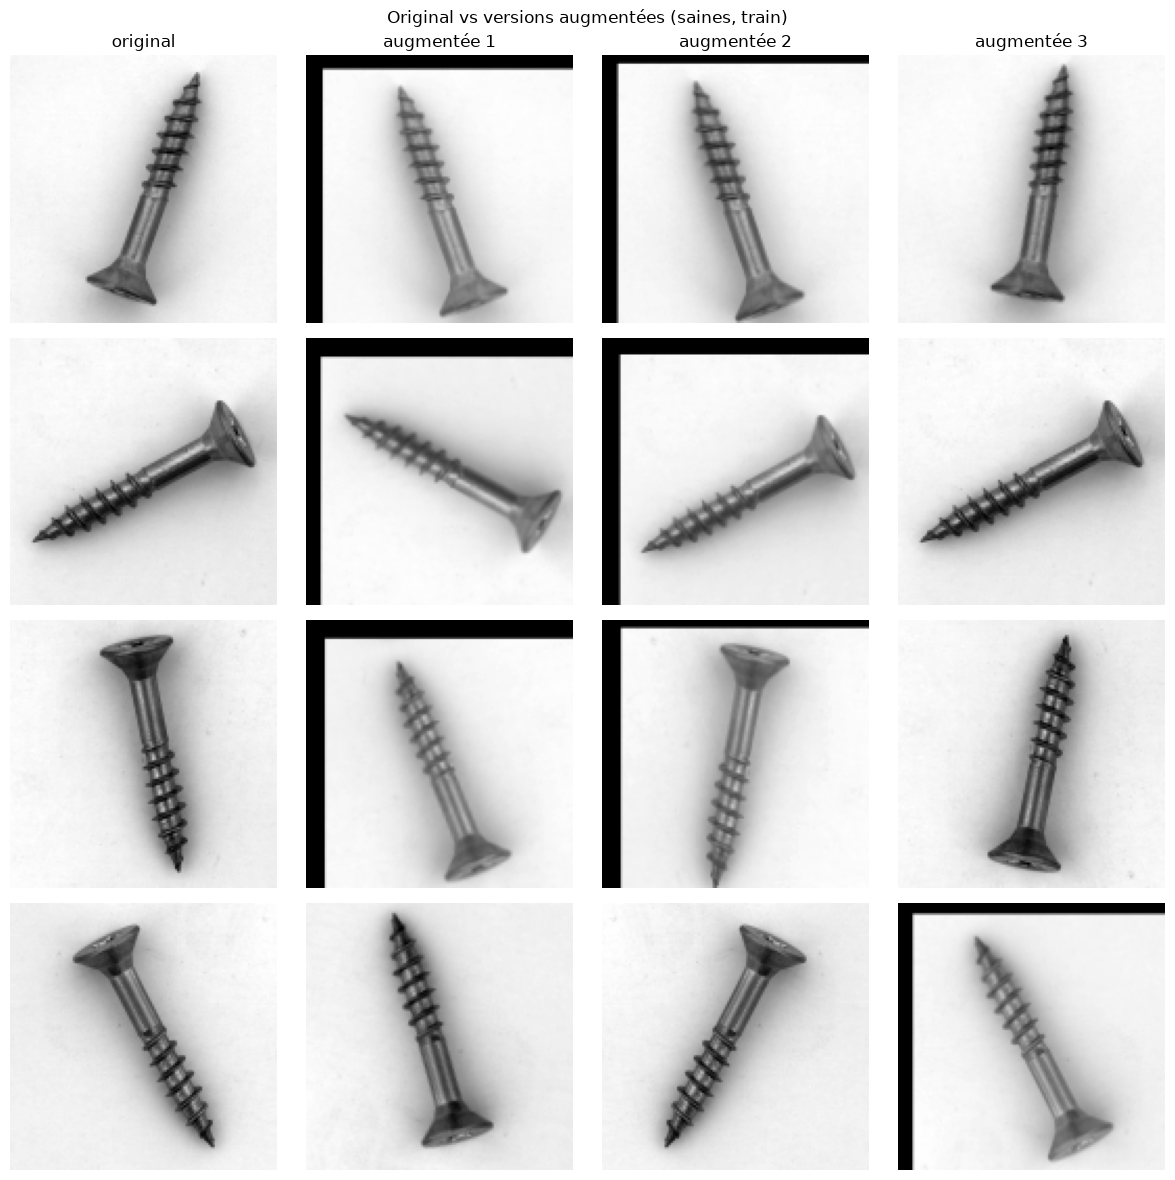

In [8]:
n_examples = 4
n_augmented = 3
fig, axes = plt.subplots(n_examples, n_augmented + 1, figsize=(3 * (n_augmented + 1), 3 * n_examples))

for i in range(n_examples):
    original = X_train[i]
    axes[i, 0].imshow(original[..., 0], cmap='gray')
    axes[i, 0].set_title('original' if i == 0 else '')
    for j in range(1, n_augmented + 1):
        augmented = augment_image(original)
        axes[i, j].imshow(augmented[..., 0], cmap='gray')
        axes[i, j].set_title(f'augmentée {j}' if i == 0 else '')

for ax in axes.ravel():
    ax.axis('off')

fig.suptitle('Original vs versions augmentées (saines, train)')
fig.tight_layout()
plt.show()

La vis est un objet **allongé mais pas parfaitement symétrique** (tête d'un côté, pointe filetée de l'autre) :
- les **flips** et **rotations larges** sont acceptables ici car les défauts recherchés (rayures, filetage
  manipulé) restent identifiables quelle que soit l'orientation, contrairement à un objet avec une orientation
  fonctionnelle stricte.
- une **rotation/translation trop forte** risquerait cependant d'élargir excessivement la notion de « normal »
  et de masquer des défauts de position ou d'orientation qui seraient eux-mêmes anormaux dans le procédé réel.
- sur une **texture** (ex. `carpet`, `wood`), l'augmentation géométrique est en général plus naturelle : la
  texture reste statistiquement homogène après rotation/translation, alors que sur un **objet centré et
  aligné**, elle peut faire apparaître au modèle des configurations qui n'existeraient jamais en production.

=> Transformations **légères** (rotation ≤ 15°, translation/échelle ≤ 5 %) 
Pas de transforamtions "elastic" ou Grid, sinon la vis saine deviendrait forcément KO, pas d'occlusion non plus, on saura pas si le défaut est dessous.

## Normalisation finale (avant modèle)

Le chargement et les transformations (étapes 1 et 2) travaillent sur les images **brutes** (`uint8`,
`[0, 255]`) — c'est le format natif attendu par OpenCV et Albumentations. La **normalisation dans `[0, 1]`**
n'intervient qu'à la toute fin, une fois les jeux finalisés, juste avant l'entrée dans le modèle (partie 2).

In [9]:
def normalize(images):
    return images.astype('float32') / 255.0


X_train_norm = normalize(X_train)
X_val_norm = normalize(X_val)
test_good_norm = normalize(test_good)
test_defects_norm = {defect: normalize(imgs) for defect, imgs in test_defects.items()}

print('X_train brut  :', X_train.dtype, X_train.min(), X_train.max())
print('X_train normé :', X_train_norm.dtype, X_train_norm.min(), X_train_norm.max())

X_train brut  : uint8 29 232
X_train normé : float32 0.11372549 0.9098039


Sauvegarde des données dans screw/train_norm.bin.gz, screw/test_good_norm.bin.gz et screw/test_defects_norm.bin.gz (dumps bruts, gzippés)

In [10]:
import gzip


def save_bin(array, path):
    with gzip.open(path, 'wb') as f:
        f.write(array.tobytes())
    print(f'{path} : {array.shape} {array.dtype} -> {path.stat().st_size / 1e6:.1f} Mo (gzip)')


save_bin(X_train_norm, DATA_DIR / 'train_norm.bin.gz')
save_bin(test_good_norm, DATA_DIR / 'test_good_norm.bin.gz')

test_defects_norm_stacked = np.concatenate([test_defects_norm[d] for d in defect_types])
save_bin(test_defects_norm_stacked, DATA_DIR / 'test_defects_norm.bin.gz')

screw/train_norm.bin.gz : (256, 128, 128, 1) float32 -> 3.2 Mo (gzip)


screw/test_good_norm.bin.gz : (41, 128, 128, 1) float32 -> 0.5 Mo (gzip)


screw/test_defects_norm.bin.gz : (119, 128, 128, 1) float32 -> 1.4 Mo (gzip)
